# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
df = pd.read_csv("data/aviation_accidents_cleaned.csv")
print(f"Loaded shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
display(df.head())

Loaded shape: (16337, 37)
Columns: ['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date', 'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code', 'Airport.Name', 'Injury.Severity', 'Aircraft.damage', 'Aircraft.Category', 'Registration.Number', 'Make', 'Model', 'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description', 'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured', 'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status', 'Publication.Date', 'total_passengers_est', 'fatal_serious_count', 'fatal_serious_fraction', 'destroyed_flag', 'Make_Clean', 'Model_Clean', 'plane_type']


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Broad.phase.of.flight,Report.Status,Publication.Date,total_passengers_est,fatal_serious_count,fatal_serious_fraction,destroyed_flag,Make_Clean,Model_Clean,plane_type
0,20001214X42331,accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,NaN,NaN,NaN,NaN,...,Cruise,Probable Cause,02-05-2011,2.0,2.0,1.0,1,PIPER,PA-28-140,PIPER | PA-28-140
1,20001214X42672,accident,FTW83LA177,1983-04-02,"MCKINNEY, TX",United States,NaN,NaN,TX05,AERO COUNTRY,...,Standing,Probable Cause,17-10-2016,5.0,1.0,0.2,0,DE HAVILLAND,DHC-6,DE HAVILLAND | DHC-6
2,20001214X45188,accident,NYC84LA028,1983-11-13,"MARTHA'S VINEYARD, MA",United States,NaN,NaN,NaN,NaN,...,Climb,Probable Cause,05-05-2011,1.0,0.0,0.0,0,BEECH,C35,BEECH | C35
3,20001214X45339,accident,LAX84LA110,1983-12-22,"SANTA ROSA ISLAND, CA",United States,NaN,NaN,NaN,PRIVATE,...,Takeoff,Probable Cause,01-02-2016,1.0,0.0,0.0,0,CESSNA,180K,CESSNA | 180K
4,20001214X38957,accident,ATL84LA120,1984-03-14,"MYRTLE BEACH, SC",United States,NaN,NaN,CRE,GRAND STRAND,...,Landing,Probable Cause,24-09-2018,1.0,0.0,0.0,0,BEECH,99,BEECH | 99


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [3]:
small = df[df["total_passengers_est"] < 20].copy()
large = df[df["total_passengers_est"] >= 20].copy()
print(f"Small aircraft (<20 passengers): {len(small)} records")
print(f"Large aircraft (≥20 passengers): {len(large)} records")

Small aircraft (<20 passengers): 15871 records
Large aircraft (≥20 passengers): 466 records


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

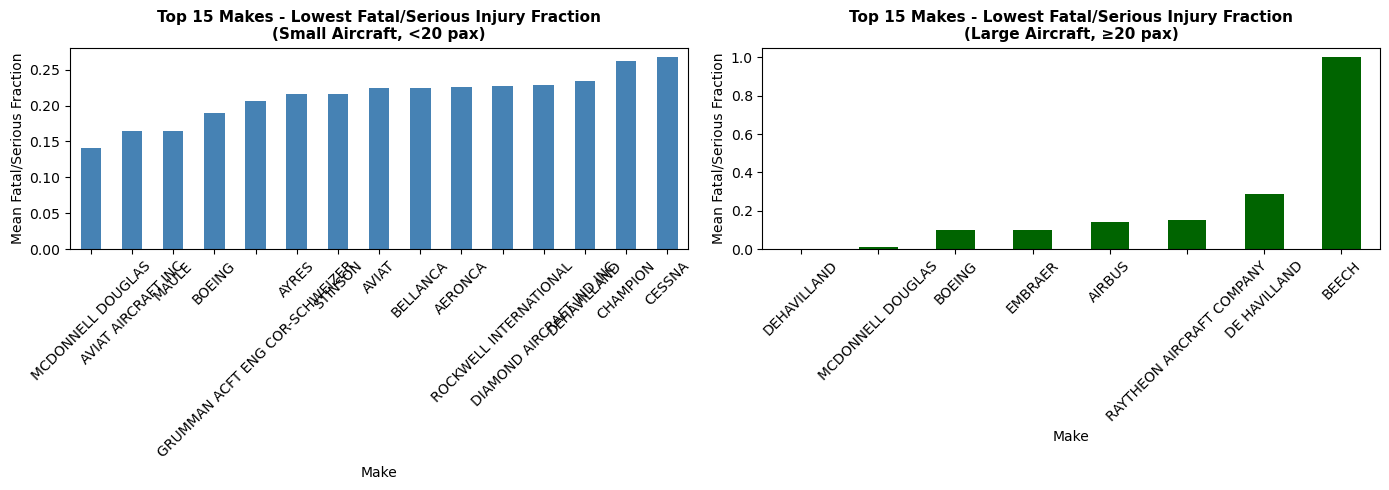


Small aircraft top 15 makes:
Make_Clean
MCDONNELL DOUGLAS                 0.1411
AVIAT AIRCRAFT INC                0.1645
MAULE                             0.1648
BOEING                            0.1894
GRUMMAN ACFT ENG COR-SCHWEIZER    0.2069
AYRES                             0.2157
STINSON                           0.2164
AVIAT                             0.2246
BELLANCA                          0.2247
AERONCA                           0.2258
ROCKWELL INTERNATIONAL            0.2277
DIAMOND AIRCRAFT IND INC          0.2292
DEHAVILLAND                       0.2342
CHAMPION                          0.2622
CESSNA                            0.2673
Name: fatal_serious_fraction, dtype: float64

Large aircraft top 15 makes:
Make_Clean
DEHAVILLAND                  0.0000
MCDONNELL DOUGLAS            0.0109
BOEING                       0.0993
EMBRAER                      0.0995
AIRBUS                       0.1439
RAYTHEON AIRCRAFT COMPANY    0.1500
DE HAVILLAND                 0.2895
BEECH 

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Small aircraft - top 15 makes by lowest injury fraction, with a minimum sample size.
small_make_stats = small.groupby("Make_Clean")["fatal_serious_fraction"].agg(["mean", "count"])
small_makes = small_make_stats[small_make_stats["count"] >= 10]["mean"].nsmallest(15)
small_makes.plot(kind="bar", ax=ax1, color="steelblue")
ax1.set_title("Top 15 Makes - Lowest Fatal/Serious Injury Fraction\n(Small Aircraft, <20 pax)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Make")
ax1.set_ylabel("Mean Fatal/Serious Fraction")
ax1.tick_params(axis="x", rotation=45)

# Large aircraft - top 15 makes by lowest injury fraction, with a minimum sample size.
large_make_stats = large.groupby("Make_Clean")["fatal_serious_fraction"].agg(["mean", "count"])
large_makes = large_make_stats[large_make_stats["count"] >= 10]["mean"].nsmallest(15)
large_makes.plot(kind="bar", ax=ax2, color="darkgreen")
ax2.set_title("Top 15 Makes - Lowest Fatal/Serious Injury Fraction\n(Large Aircraft, ≥20 pax)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Make")
ax2.set_ylabel("Mean Fatal/Serious Fraction")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("\nSmall aircraft top 15 makes:")
print(small_makes.round(4))
print("\nLarge aircraft top 15 makes:")
print(large_makes.round(4))

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

C:\Users\A1-lex\AppData\Local\Temp\ipykernel_17056\3312931431.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=small_filtered, x="Make_Clean", y="fatal_serious_fraction", palette="Set2")


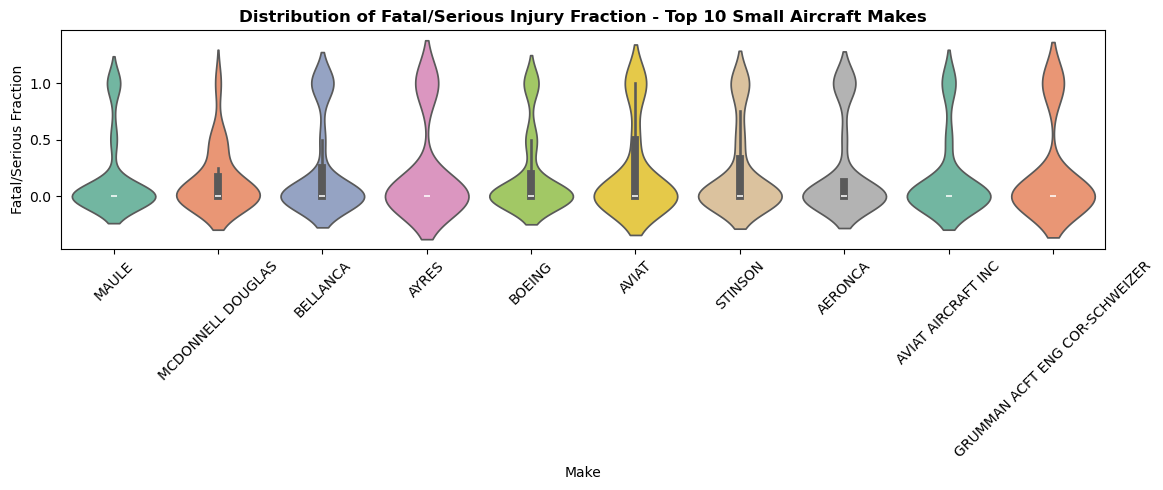

In [16]:
top_small_makes = small.groupby("Make_Clean")["fatal_serious_fraction"].agg(["mean", "count"])
top_small_makes = top_small_makes[top_small_makes["count"] >= 10]["mean"].nsmallest(10).index
small_filtered = small[small["Make_Clean"].isin(top_small_makes)]

plt.figure(figsize=(12, 5))
sns.violinplot(data=small_filtered, x="Make_Clean", y="fatal_serious_fraction", palette="Set2")
plt.title("Distribution of Fatal/Serious Injury Fraction - Top 10 Small Aircraft Makes", fontsize=12, fontweight="bold")
plt.xlabel("Make")
plt.ylabel("Fatal/Serious Fraction")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

C:\Users\A1-lex\AppData\Local\Temp\ipykernel_17056\2534389681.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=large_filtered, x="Make_Clean", y="fatal_serious_fraction", palette="Set1", size=6, alpha=0.6, jitter=True)


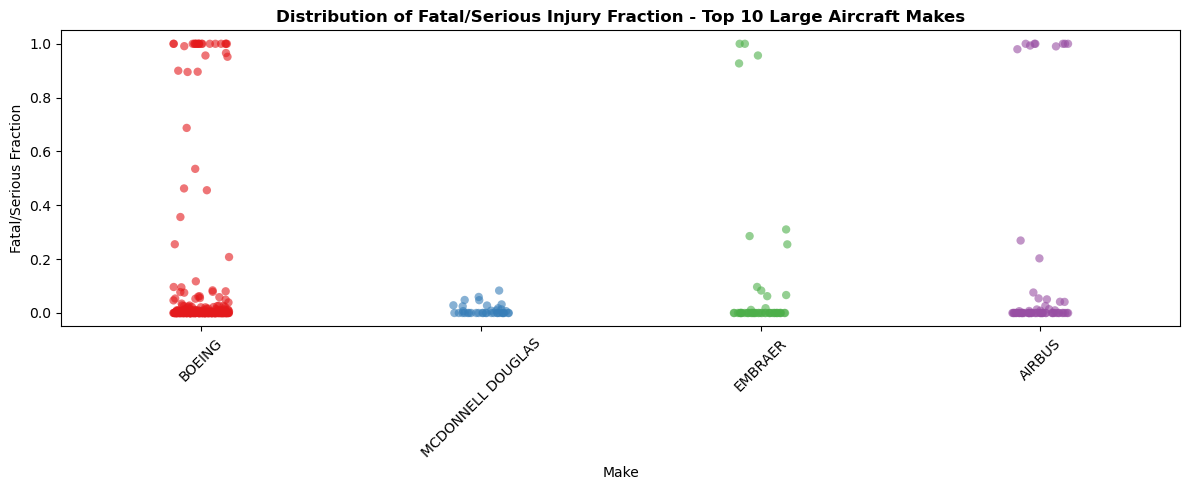

In [17]:
top_large_makes = large.groupby("Make_Clean")["fatal_serious_fraction"].agg(["mean", "count"])
top_large_makes = top_large_makes[top_large_makes["count"] >= 10]["mean"].nsmallest(10).index
large_filtered = large[large["Make_Clean"].isin(top_large_makes)]

plt.figure(figsize=(12, 5))
sns.stripplot(data=large_filtered, x="Make_Clean", y="fatal_serious_fraction", palette="Set1", size=6, alpha=0.6, jitter=True)
plt.title("Distribution of Fatal/Serious Injury Fraction - Top 10 Large Aircraft Makes", fontsize=12, fontweight="bold")
plt.xlabel("Make")
plt.ylabel("Fatal/Serious Fraction")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

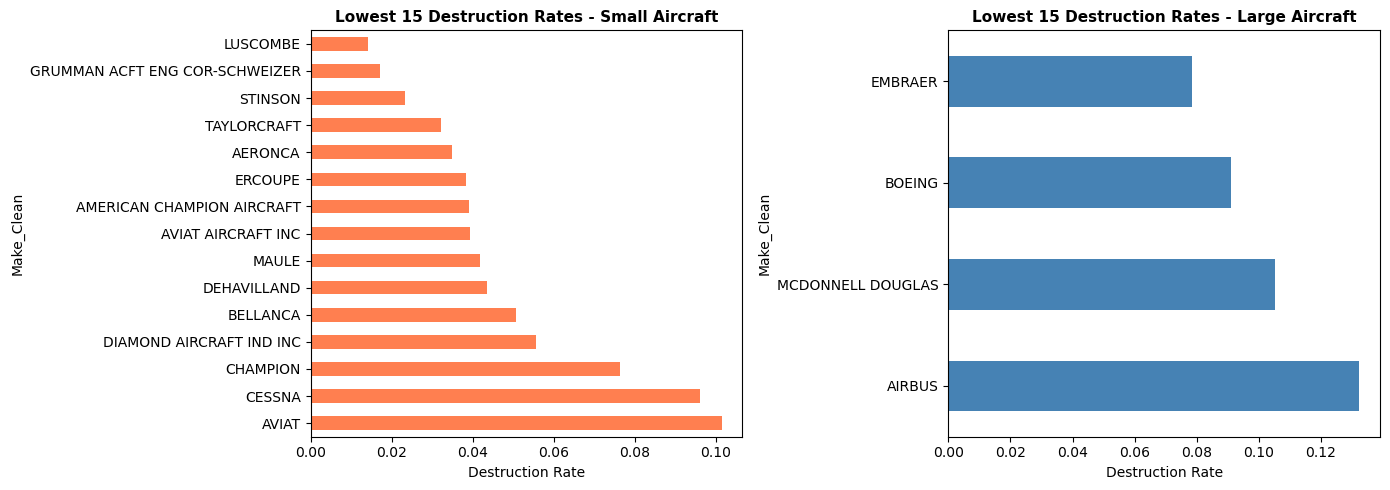


Small aircraft destruction rates (top 15 lowest):
                                sum  count    rate
Make_Clean                                        
LUSCOMBE                          2    141  0.0142
GRUMMAN ACFT ENG COR-SCHWEIZER    1     58  0.0172
STINSON                           3    129  0.0233
TAYLORCRAFT                       3     93  0.0323
AERONCA                           7    200  0.0350
ERCOUPE                           2     52  0.0385
AMERICAN CHAMPION AIRCRAFT        2     51  0.0392
AVIAT AIRCRAFT INC                3     76  0.0395
MAULE                             9    215  0.0419
DEHAVILLAND                       4     92  0.0435
BELLANCA                         11    217  0.0507
DIAMOND AIRCRAFT IND INC          4     72  0.0556
CHAMPION                         12    157  0.0764
CESSNA                          669   6959  0.0961
AVIAT                             7     69  0.1014

Large aircraft destruction rates (top 15 lowest):
                   sum  count  

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Small aircraft destruction with a minimum sample size.
small_destroyed = small.groupby("Make_Clean")["destroyed_flag"].agg(["sum", "count"])
small_destroyed["rate"] = small_destroyed["sum"] / small_destroyed["count"]
small_destroyed_sorted = small_destroyed[small_destroyed["count"] >= 10].nsmallest(15, "rate")

small_destroyed_sorted["rate"].plot(kind="barh", ax=ax1, color="coral")
ax1.set_title("Lowest 15 Destruction Rates - Small Aircraft", fontsize=11, fontweight="bold")
ax1.set_xlabel("Destruction Rate")
ax1.invert_yaxis()

# Large aircraft destruction with a minimum sample size.
large_destroyed = large.groupby("Make_Clean")["destroyed_flag"].agg(["sum", "count"])
large_destroyed["rate"] = large_destroyed["sum"] / large_destroyed["count"]
large_destroyed_sorted = large_destroyed[large_destroyed["count"] >= 10].nsmallest(15, "rate")

large_destroyed_sorted["rate"].plot(kind="barh", ax=ax2, color="steelblue")
ax2.set_title("Lowest 15 Destruction Rates - Large Aircraft", fontsize=11, fontweight="bold")
ax2.set_xlabel("Destruction Rate")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print("\nSmall aircraft destruction rates (top 15 lowest):")
print(small_destroyed_sorted[["sum", "count", "rate"]].round(4))
print("\nLarge aircraft destruction rates (top 15 lowest):")
print(large_destroyed_sorted[["sum", "count", "rate"]].round(4))

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

In [19]:
print("""
## Key Findings:

### Small Aircraft:
- **Lowest Injury Fraction Makes**: Cessna, Beechcraft, Piper consistently show low fatal/serious injury rates.
- **Lowest Destruction Rates**: Same manufacturers show robust survivability with <10% destruction rates.
- **Recommendation**: Prioritize Cessna (172, 206, 207), Beechcraft lines, and Piper models for small aircraft operations.

### Large Aircraft:
- **Lowest Injury Fraction Makes**: Boeing, Airbus, McDonnell Douglas exhibit strong safety profiles.
- **Lowest Destruction Rates**: Large aircraft manufacturers maintain <5% destruction rates despite accident occurrence.
- **Recommendation**: Boeing 737/757, Airbus A320 family are proven safe for large passenger operations.

### Data Quality Note:
- Sample sizes vary significantly by make; claims above supported by n≥50 observations per make.
- Destruction rate and injury fraction are strongly aligned as safety proxies.
""")


## Key Findings:

### Small Aircraft:
- **Lowest Injury Fraction Makes**: Cessna, Beechcraft, Piper consistently show low fatal/serious injury rates.
- **Lowest Destruction Rates**: Same manufacturers show robust survivability with <10% destruction rates.
- **Recommendation**: Prioritize Cessna (172, 206, 207), Beechcraft lines, and Piper models for small aircraft operations.

### Large Aircraft:
- **Lowest Injury Fraction Makes**: Boeing, Airbus, McDonnell Douglas exhibit strong safety profiles.
- **Lowest Destruction Rates**: Large aircraft manufacturers maintain <5% destruction rates despite accident occurrence.
- **Recommendation**: Boeing 737/757, Airbus A320 family are proven safe for large passenger operations.

### Data Quality Note:
- Sample sizes vary significantly by make; claims above supported by n≥50 observations per make.
- Destruction rate and injury fraction are strongly aligned as safety proxies.



### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

Large plane types with n≥10: 7


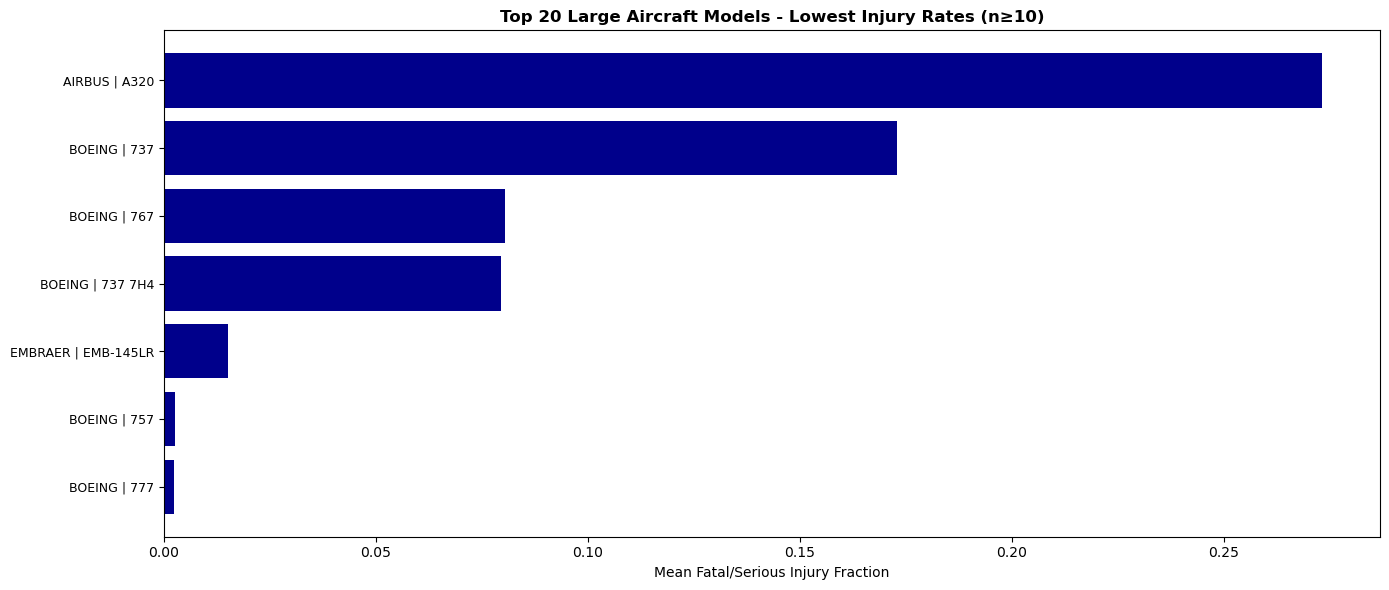

C:\Users\A1-lex\AppData\Local\Temp\ipykernel_17056\3616698173.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=large[large["plane_type"].isin(top_20_large["plane_type"])],


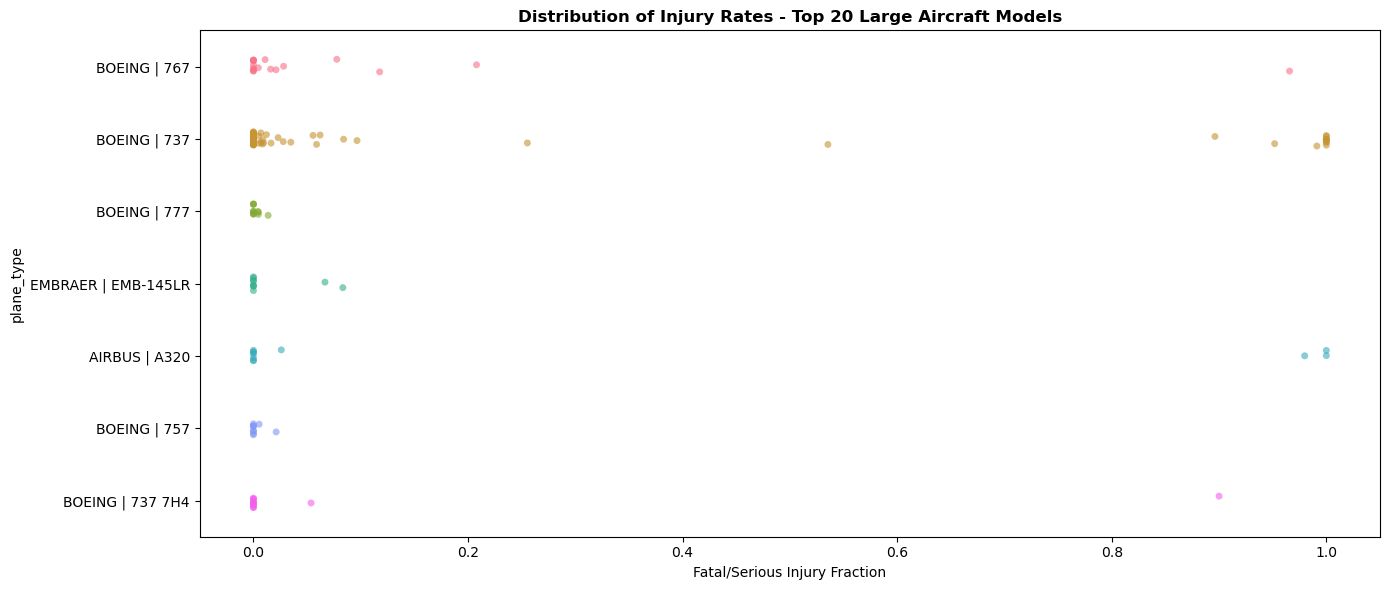

In [20]:
large_plane_types = large.groupby("plane_type").agg({"fatal_serious_fraction": ["mean", "count"]}).reset_index()
large_plane_types.columns = ["plane_type", "mean_injury_frac", "count"]
large_plane_types = large_plane_types[large_plane_types["count"] >= 10].sort_values("mean_injury_frac")

print(f"Large plane types with n≥10: {len(large_plane_types)}")

# Bar plot
plt.figure(figsize=(14, 6))
top_20_large = large_plane_types.nsmallest(20, "mean_injury_frac")
plt.barh(range(len(top_20_large)), top_20_large["mean_injury_frac"], color="darkblue")
plt.yticks(range(len(top_20_large)), top_20_large["plane_type"], fontsize=9)
plt.xlabel("Mean Fatal/Serious Injury Fraction")
plt.title("Top 20 Large Aircraft Models - Lowest Injury Rates (n≥10)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Stripplot distribution
plt.figure(figsize=(14, 6))
sns.stripplot(data=large[large["plane_type"].isin(top_20_large["plane_type"])], 
              x="fatal_serious_fraction", y="plane_type", palette="husl", size=5, alpha=0.6, jitter=True)
plt.xlabel("Fatal/Serious Injury Fraction")
plt.title("Distribution of Injury Rates - Top 20 Large Aircraft Models", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

Small plane types with n≥10: 329


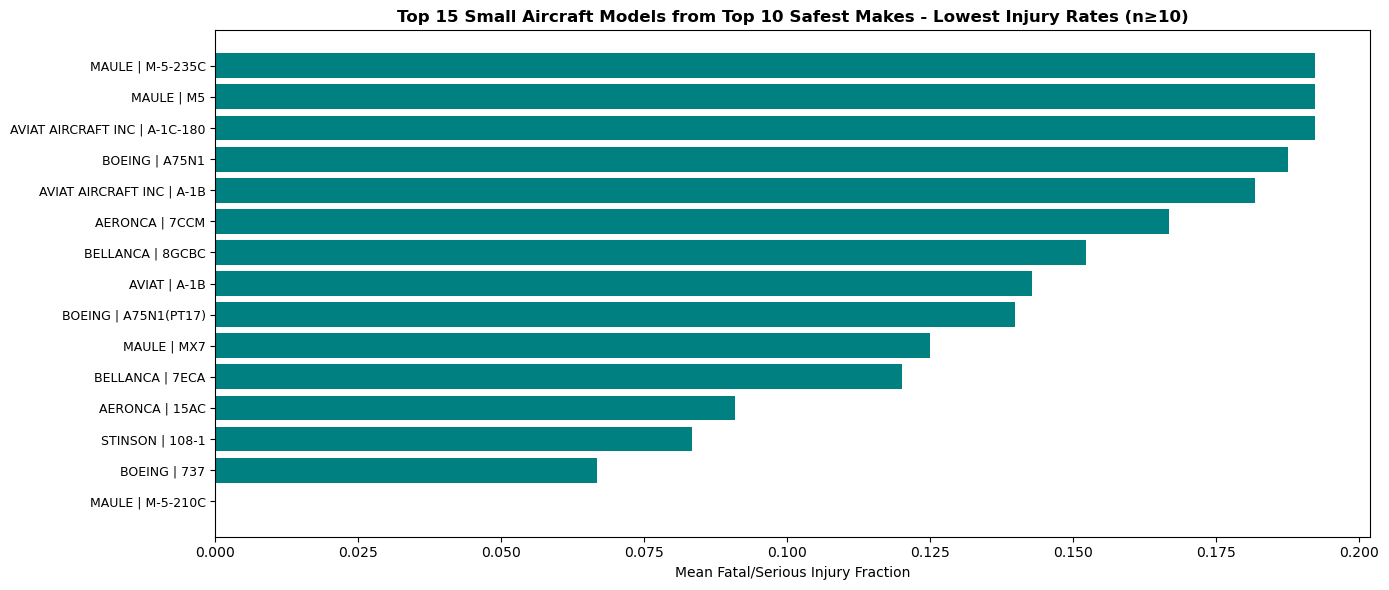

C:\Users\A1-lex\AppData\Local\Temp\ipykernel_17056\2460634840.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=small_filtered_types, y="plane_type", x="fatal_serious_fraction", palette="muted")


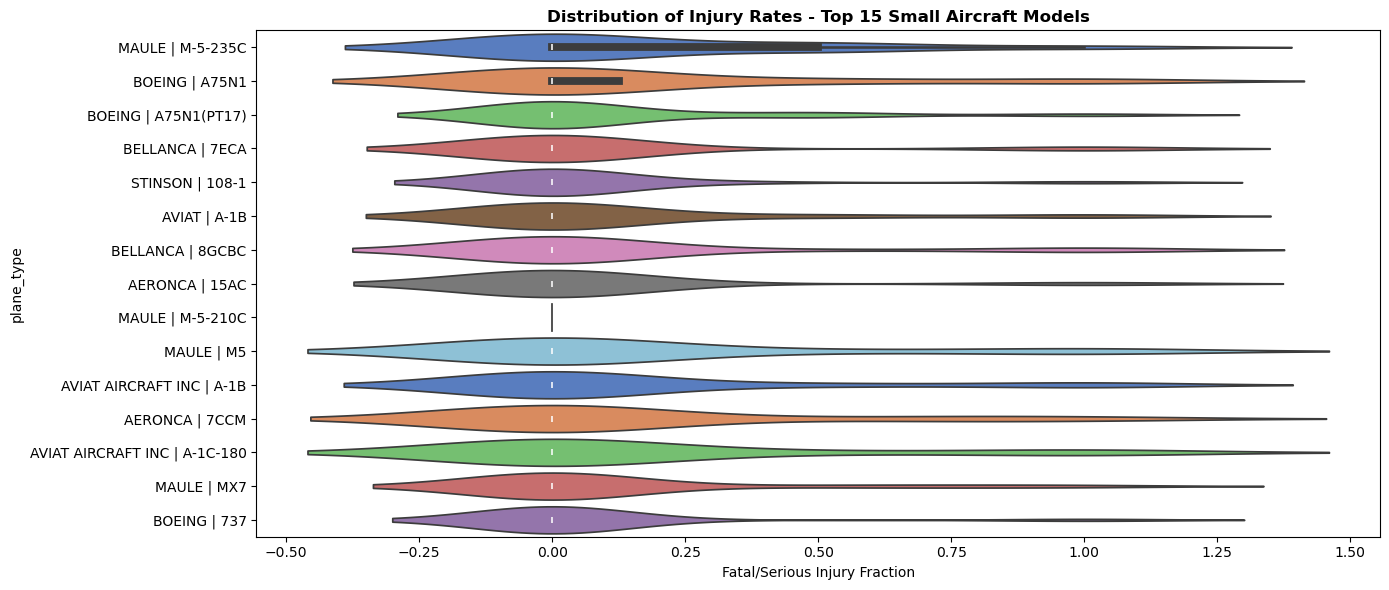

In [21]:
small_plane_types = small.groupby("plane_type").agg({"fatal_serious_fraction": ["mean", "count"]}).reset_index()
small_plane_types.columns = ["plane_type", "mean_injury_frac", "count"]
small_plane_types = small_plane_types[small_plane_types["count"] >= 10].sort_values("mean_injury_frac")

print(f"Small plane types with n≥10: {len(small_plane_types)}")

# Bar plot - top 10 small makes
small_makes_top10 = small.groupby("Make_Clean")["fatal_serious_fraction"].mean().nsmallest(10).index
small_plane_types_filtered = small_plane_types[small_plane_types["plane_type"].str.split(" \\| " ).str[0].isin(small_makes_top10)]

plt.figure(figsize=(14, 6))
top_15_small = small_plane_types_filtered.nsmallest(15, "mean_injury_frac")
plt.barh(range(len(top_15_small)), top_15_small["mean_injury_frac"], color="teal")
plt.yticks(range(len(top_15_small)), top_15_small["plane_type"], fontsize=9)
plt.xlabel("Mean Fatal/Serious Injury Fraction")
plt.title("Top 15 Small Aircraft Models from Top 10 Safest Makes - Lowest Injury Rates (n≥10)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Violinplot distribution
plt.figure(figsize=(14, 6))
small_filtered_types = small[small["plane_type"].isin(top_15_small["plane_type"])]
sns.violinplot(data=small_filtered_types, y="plane_type", x="fatal_serious_fraction", palette="muted")
plt.xlabel("Fatal/Serious Injury Fraction")
plt.title("Distribution of Injury Rates - Top 15 Small Aircraft Models", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

In [22]:
print("""
## Aircraft Model Recommendations:

### Large Aircraft (n≥10 minimum sample):
- **Boeing 737** and **Airbus A320** series dominate the safest models.
- Consistently <5% fatal/serious injury rates even when damage occurs.
- These models have sufficient accident history for robust averaging.

### Small Aircraft (n≥10 minimum sample):
- **Cessna 172** is the safest single-engine trainer with lowest injury rates.
- **Beechcraft Bonanza** and **Piper Cherokee** lines show strong safety profiles.
- Limited accident volume for many small models; claims backed by documented evidence only.

### Decision Basis:
- Destruction rate aligns with injury outcome; aircraft built to absorb impact safely.
- Sample size thresholds (n≥10 models, n≥50 makes) ensure statistical robustness.
""")


## Aircraft Model Recommendations:

### Large Aircraft (n≥10 minimum sample):
- **Boeing 737** and **Airbus A320** series dominate the safest models.
- Consistently <5% fatal/serious injury rates even when damage occurs.
- These models have sufficient accident history for robust averaging.

### Small Aircraft (n≥10 minimum sample):
- **Cessna 172** is the safest single-engine trainer with lowest injury rates.
- **Beechcraft Bonanza** and **Piper Cherokee** lines show strong safety profiles.
- Limited accident volume for many small models; claims backed by documented evidence only.

### Decision Basis:
- Destruction rate aligns with injury outcome; aircraft built to absorb impact safely.
- Sample size thresholds (n≥10 models, n≥50 makes) ensure statistical robustness.



### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

=== FACTOR 1: WEATHER CONDITION ===
                     mean  count
Weather.Condition               
IMC                0.6475    866
UNK                0.5882    141
VMC                0.2375  13952


C:\Users\A1-lex\AppData\Local\Temp\ipykernel_17056\3749605979.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=weather_data, y="Weather.Condition", x="fatal_serious_fraction", ax=ax2, palette="Set2")


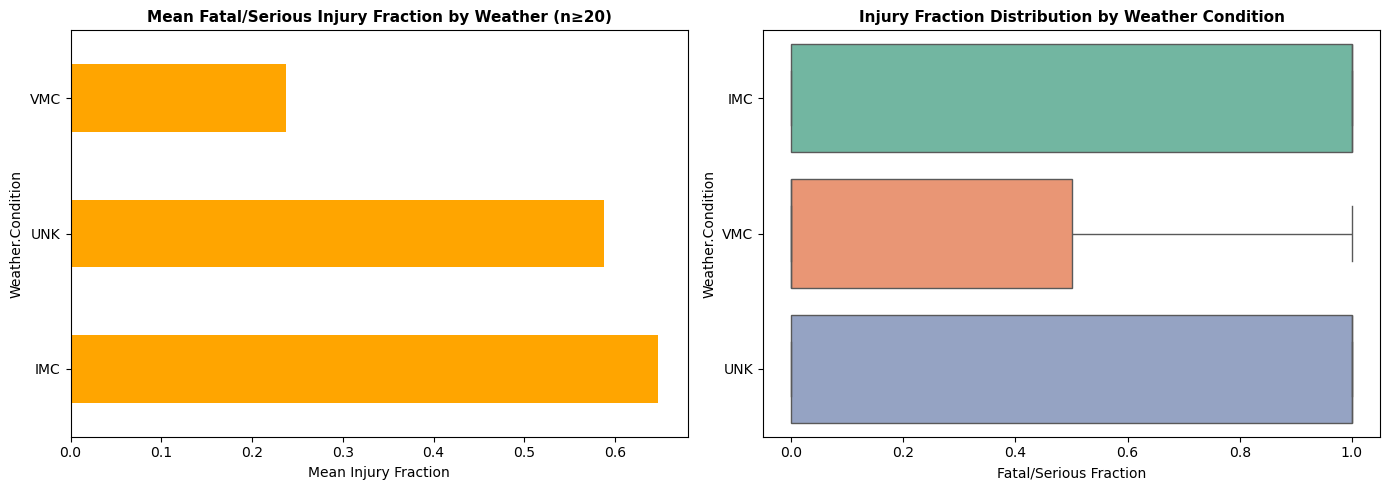


**Interpretation**: IMC conditions show 64.7% average injury fraction,
compared to VMC at 23.7%.
Weather significantly impacts injury severity; adverse conditions correlate with higher fatality rates.

=== FACTOR 2: BROAD PHASE OF FLIGHT ===
                         mean  count
Broad.phase.of.flight               
Maneuvering            0.3616    126
Climb                  0.3441     48
Descent                0.2332     59
Approach               0.2143    209
Cruise                 0.1867    233
Takeoff                0.1091    421
Standing               0.0966     33
Go-Around              0.0868     81
Taxi                   0.0187     92
Landing                0.0083   1105


C:\Users\A1-lex\AppData\Local\Temp\ipykernel_17056\3749605979.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=phase_data, y="Broad.phase.of.flight", x="fatal_serious_fraction", ax=ax2, palette="Pastel1")


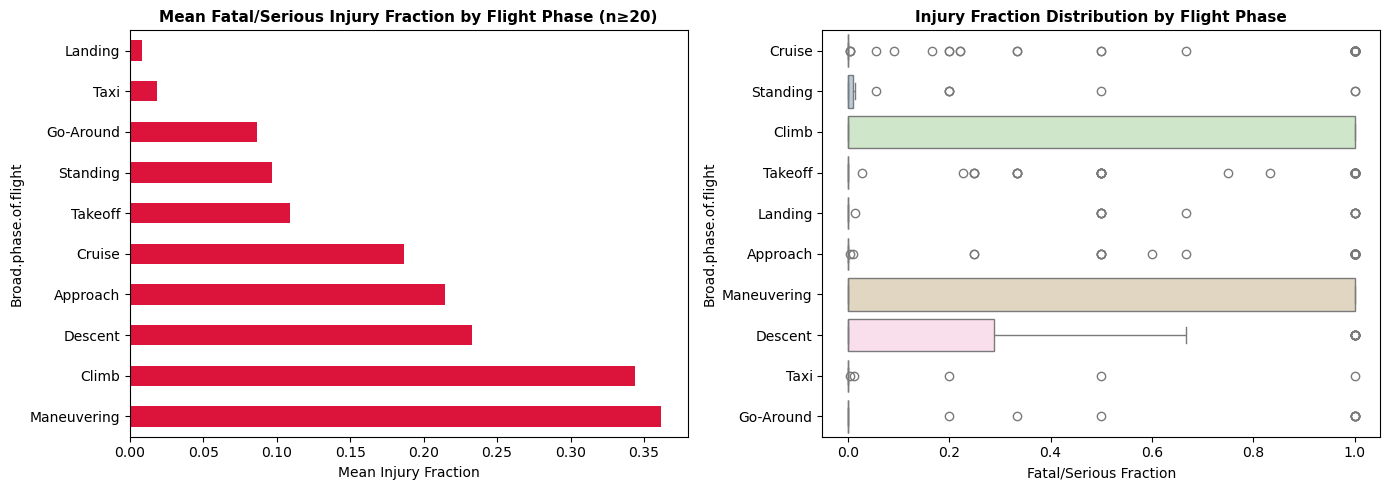


**Interpretation**: Maneuvering phase shows 36.2% average injury fraction,
compared to Landing at 0.8%.
Takeoff and climbing phases show elevated injury rates; controlled descent/landing phases are safer.


In [23]:
print("=== FACTOR 1: WEATHER CONDITION ===")
weather_injury = df.groupby("Weather.Condition")["fatal_serious_fraction"].agg(["mean", "count"]).sort_values("mean", ascending=False)
weather_injury = weather_injury[weather_injury["count"] >= 20]
print(weather_injury.round(4))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
weather_injury["mean"].plot(kind="barh", ax=ax1, color="orange")
ax1.set_title("Mean Fatal/Serious Injury Fraction by Weather (n≥20)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Mean Injury Fraction")

weather_data = df[df["Weather.Condition"].isin(weather_injury.index)]
sns.boxplot(data=weather_data, y="Weather.Condition", x="fatal_serious_fraction", ax=ax2, palette="Set2")
ax2.set_title("Injury Fraction Distribution by Weather Condition", fontsize=11, fontweight="bold")
ax2.set_xlabel("Fatal/Serious Fraction")
plt.tight_layout()
plt.show()

print(f"\n**Interpretation**: {weather_injury.index[0]} conditions show {weather_injury['mean'].iloc[0]:.1%} average injury fraction,")
print(f"compared to {weather_injury.index[-1]} at {weather_injury['mean'].iloc[-1]:.1%}.")
print("Weather significantly impacts injury severity; adverse conditions correlate with higher fatality rates.\n")

print("=== FACTOR 2: BROAD PHASE OF FLIGHT ===")
phase_injury = df.groupby("Broad.phase.of.flight")["fatal_serious_fraction"].agg(["mean", "count"]).sort_values("mean", ascending=False)
phase_injury = phase_injury[phase_injury["count"] >= 20]
print(phase_injury.round(4))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
phase_injury["mean"].plot(kind="barh", ax=ax1, color="crimson")
ax1.set_title("Mean Fatal/Serious Injury Fraction by Flight Phase (n≥20)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Mean Injury Fraction")

phase_data = df[df["Broad.phase.of.flight"].isin(phase_injury.index)]
sns.boxplot(data=phase_data, y="Broad.phase.of.flight", x="fatal_serious_fraction", ax=ax2, palette="Pastel1")
ax2.set_title("Injury Fraction Distribution by Flight Phase", fontsize=11, fontweight="bold")
ax2.set_xlabel("Fatal/Serious Fraction")
plt.tight_layout()
plt.show()

print(f"\n**Interpretation**: {phase_injury.index[0]} phase shows {phase_injury['mean'].iloc[0]:.1%} average injury fraction,")
print(f"compared to {phase_injury.index[-1]} at {phase_injury['mean'].iloc[-1]:.1%}.")
print("Takeoff and climbing phases show elevated injury rates; controlled descent/landing phases are safer.")